In [1]:
import pandas as pd
import numpy as np
from importlib import reload
from preprocessor.preprocessor import TransactionPreprocessor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay

In [2]:
pd.set_option('display.max_columns', 60)

In [3]:
df = pd.read_csv('cleaned.csv')
df

,transaction_id,user_id,amount,country,timestamp,is_fraud
0,6253,3594,125.79,US,28-01-2023 06:04,0
1,4685,2502,153.40,DE,27-04-2023 21:32,0
2,1732,2287,7.64,IN,19-08-2023 19:03,0
3,4743,3043,36.36,US,14-03-2023 04:56,0
4,4522,4629,55.17,ES,24-09-2023 21:33,0
...,...,...,...,...,...,...
9995,5735,1520,10.74,ES,21-02-2023 06:20,0
9996,5192,1648,76.97,BR,02-09-2023 12:51,0
9997,5391,2776,56.48,AU,18-01-2023 13:41,0
9998,861,2856,6.64,US,15-04-2023 15:25,0


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

C:\Users\utkarsh.gupta\AppData\Local\Temp\ipykernel_11972\1067626418.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')


In [5]:
df['date_of_transaction'] = df['timestamp'].dt.date
df['time_of_transaction'] = df['timestamp'].dt.time

In [6]:
df = df.rename({
    'transaction_id': 'transaction_id',
    'user_id': 'user_id',
    'amount': 'amount',
    'country': 'currency',
    'timestamp': 'timestamp',
    'date_of_transaction': 'date_of_transaction',
    'time_of_transaction': 'time_of_transaction',
    'is_fraud': 'is_fraud'
}, axis=1)

In [7]:
df = df.drop(['timestamp'], axis=1)

In [8]:
df['currency'] = df['currency'].astype('category')

In [9]:
df

,transaction_id,user_id,amount,currency,is_fraud,date_of_transaction,time_of_transaction
0,6253,3594,125.79,US,0,2023-01-28,06:04:00
1,4685,2502,153.40,DE,0,2023-04-27,21:32:00
2,1732,2287,7.64,IN,0,2023-08-19,19:03:00
3,4743,3043,36.36,US,0,2023-03-14,04:56:00
4,4522,4629,55.17,ES,0,2023-09-24,21:33:00
...,...,...,...,...,...,...,...
9995,5735,1520,10.74,ES,0,2023-02-21,06:20:00
9996,5192,1648,76.97,BR,0,2023-09-02,12:51:00
9997,5391,2776,56.48,AU,0,2023-01-18,13:41:00
9998,861,2856,6.64,US,0,2023-04-15,15:25:00


In [10]:
df.isnull().sum()

transaction_id         0
user_id                0
amount                 0
currency               0
is_fraud               0
date_of_transaction    0
time_of_transaction    0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   transaction_id       10000 non-null  int64   
 1   user_id              10000 non-null  int64   
 2   amount               10000 non-null  float64 
 3   currency             10000 non-null  category
 4   is_fraud             10000 non-null  int64   
 5   date_of_transaction  10000 non-null  object  
 6   time_of_transaction  10000 non-null  object  
dtypes: category(1), float64(1), int64(3), object(2)
memory usage: 479.0+ KB


In [12]:
df['user_id'].value_counts()

user_id
3708    10
4854    10
1684     9
1661     9
3773     9
        ..
1751     1
2780     1
2309     1
2020     1
4000     1
Name: count, Length: 3664, dtype: int64

In [13]:
df['currency'].unique()

['US', 'DE', 'IN', 'ES', 'JP', 'BR', 'UK', 'FR', 'CA', 'AU']
Categories (10, object): ['AU', 'BR', 'CA', 'DE', ..., 'IN', 'JP', 'UK', 'US']

In [14]:
preprocessed_df = df.copy()
preprocessor = TransactionPreprocessor()
preprocessed_df = preprocessor.get_amount_features(preprocessed_df)
preprocessed_df = preprocessor.get_currency_features(preprocessed_df)
preprocessed_df = preprocessor.get_datetime_features(preprocessed_df)
preprocessed_df = preprocessor.get_velocity_features(preprocessed_df)

C:\Users\utkarsh.gupta\Fraud-Detection\src\research\preprocessor\currencyFeatures.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['user_id', 'currency'])
C:\Users\utkarsh.gupta\Fraud-Detection\src\research\preprocessor\velocityFeatures.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .rolling(window)
C:\Users\utkarsh.gupta\Fraud-Detection\src\research\preprocessor\velocityFeatures.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .rolling(window)
C:\Users\utkarsh.gupta\Fraud-Detection\src\research\preprocessor\velocityFeatures.py:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .rolling(window)
C:\Users\utkarsh.gu

In [15]:
preprocessed_df

,transaction_ts,transaction_id,user_id,amount,currency,is_fraud,date_of_transaction,time_of_transaction,amount_normalized,log_amount,amount_rank_user,user_avg_amount,amount_vs_user_avg,amount_minus_user_avg,user_std_amount,amount_zscore_user,amount_percentile_user,is_new_currency_for_user,currency_txn_count_user,total_txn_count_user,currency_txn_ratio_user,num_unique_currencies_user,currency_diversity_user,num_unique_currencies_user_last_7D,hour_of_day,minute_of_hour,day_of_week,day_of_month,week_of_year,month,year,is_weekend,is_night_txn,hour_sin,hour_cos,dow_sin,dow_cos,time_since_last_txn_user,avg_time_between_txns_user,txn_count_user_last_5min,txn_count_user_last_1H,txn_count_user_last_24H,sum_amount_user_last_1H,max_amount_user_last_1H,sum_amount_user_last_24H,max_amount_user_last_24H,min_time_gap_user_last_5_txns
0,2023-09-21 14:10:00,4524,1000,72.76,IN,0,2023-09-21,14:10:00,-0.114491,4.300817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,14,10,3,21,38,9,2023,0,0,-0.500000,-8.660254e-01,0.433884,-0.900969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-15 00:29:00,2989,1001,44.10,IN,0,2023-02-15,00:29:00,-0.580764,3.808882,1.0,72.760000,0.606102,-28.660000,NaN,NaN,1.000000,1.0,0,0,NaN,1.0,NaN,1.0,0,29,2,15,7,2,2023,0,1,0.000000,1.000000e+00,0.974928,-0.222521,NaN,NaN,1.0,1.0,1.0,72.76,72.76,72.76,72.76,NaN
2,2023-05-18 00:06:00,289,1001,67.08,CA,1,2023-05-18,00:06:00,-0.206900,4.220683,1.0,44.100000,1.521088,22.980000,NaN,NaN,1.000000,1.0,0,1,0.0,1.0,1.0,1.0,0,6,3,18,20,5,2023,0,1,0.000000,1.000000e+00,0.433884,-0.900969,7947420.0,NaN,1.0,1.0,1.0,44.10,44.10,44.10,44.10,NaN
3,2023-07-03 18:02:00,9428,1001,28.94,JP,0,2023-07-03,18:02:00,-0.827403,3.399195,1.0,55.590000,0.520597,-26.650000,16.249314,-1.640069,1.000000,1.0,0,2,0.0,2.0,1.0,1.0,18,2,0,3,27,7,2023,0,0,-1.000000,-1.836970e-16,0.000000,1.000000,4038960.0,7947420.0,1.0,1.0,1.0,67.08,67.08,67.08,67.08,NaN
4,2023-07-04 20:07:00,2675,1001,156.89,US,0,2023-07-04,20:07:00,1.254228,5.061899,0.5,46.706667,3.359049,110.183333,19.203149,5.737774,0.333333,1.0,0,3,0.0,3.0,1.0,1.0,20,7,1,4,27,7,2023,0,0,-0.866025,5.000000e-01,0.781831,0.623490,93900.0,5993190.0,1.0,1.0,1.0,28.94,28.94,28.94,28.94,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-10-08 05:22:00,6674,4997,132.03,ES,0,2023-10-08,05:22:00,0.849778,4.890575,0.6,125.768000,1.049790,6.262000,61.801009,0.101325,0.400000,1.0,0,0,NaN,5.0,NaN,1.0,5,22,6,8,40,10,2023,1,1,0.965926,2.588190e-01,-0.781831,0.623490,NaN,6622425.0,1.0,1.0,1.0,78.71,78.71,78.71,78.71,NaN
9996,2023-02-27 15:10:00,9173,4998,42.37,US,0,2023-02-27,15:10:00,-0.608909,3.769768,1.0,132.030000,0.320912,-89.660000,NaN,NaN,1.000000,1.0,0,0,NaN,1.0,NaN,1.0,15,10,0,27,9,2,2023,0,0,-0.707107,-7.071068e-01,0.000000,1.000000,NaN,NaN,1.0,1.0,1.0,132.03,132.03,132.03,132.03,NaN
9997,2023-06-16 06:23:00,2271,4998,11.30,AU,0,2023-06-16,06:23:00,-1.114390,2.509599,1.0,42.370000,0.266698,-31.070000,NaN,NaN,1.000000,1.0,0,1,0.0,1.0,1.0,1.0,6,23,4,16,24,6,2023,0,0,1.000000,6.123234e-17,-0.433884,-0.900969,9385980.0,NaN,1.0,1.0,1.0,42.37,42.37,42.37,42.37,NaN
9998,2023-04-01 20:43:00,7544,4999,25.61,US,0,2023-04-01,20:43:00,-0.881579,3.281287,1.0,26.835000,0.954351,-1.225000,21.969808,-0.055758,0.500000,1.0,0,0,NaN,2.0,NaN,1.0,20,43,5,1,13,4,2023,1,0,-0.866025,5.000000e-01,-0.974928,-0.222521,NaN,9385980.0,1.0,1.0,1.0,11.30,11.30,11.30,11.30,NaN


In [16]:
preprocessed_df = preprocessed_df.drop(['currency', 'transaction_ts', 'date_of_transaction', 'time_of_transaction'], axis=1)

In [17]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 43 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   transaction_id                      10000 non-null  int64  
 1   user_id                             10000 non-null  int64  
 2   amount                              10000 non-null  float64
 3   is_fraud                            10000 non-null  int64  
 4   amount_normalized                   10000 non-null  float64
 5   log_amount                          10000 non-null  float64
 6   amount_rank_user                    9999 non-null   float64
 7   user_avg_amount                     9999 non-null   float64
 8   amount_vs_user_avg                  9999 non-null   float64
 9   amount_minus_user_avg               9999 non-null   float64
 10  user_std_amount                     6335 non-null   float64
 11  amount_zscore_user                  6334 n

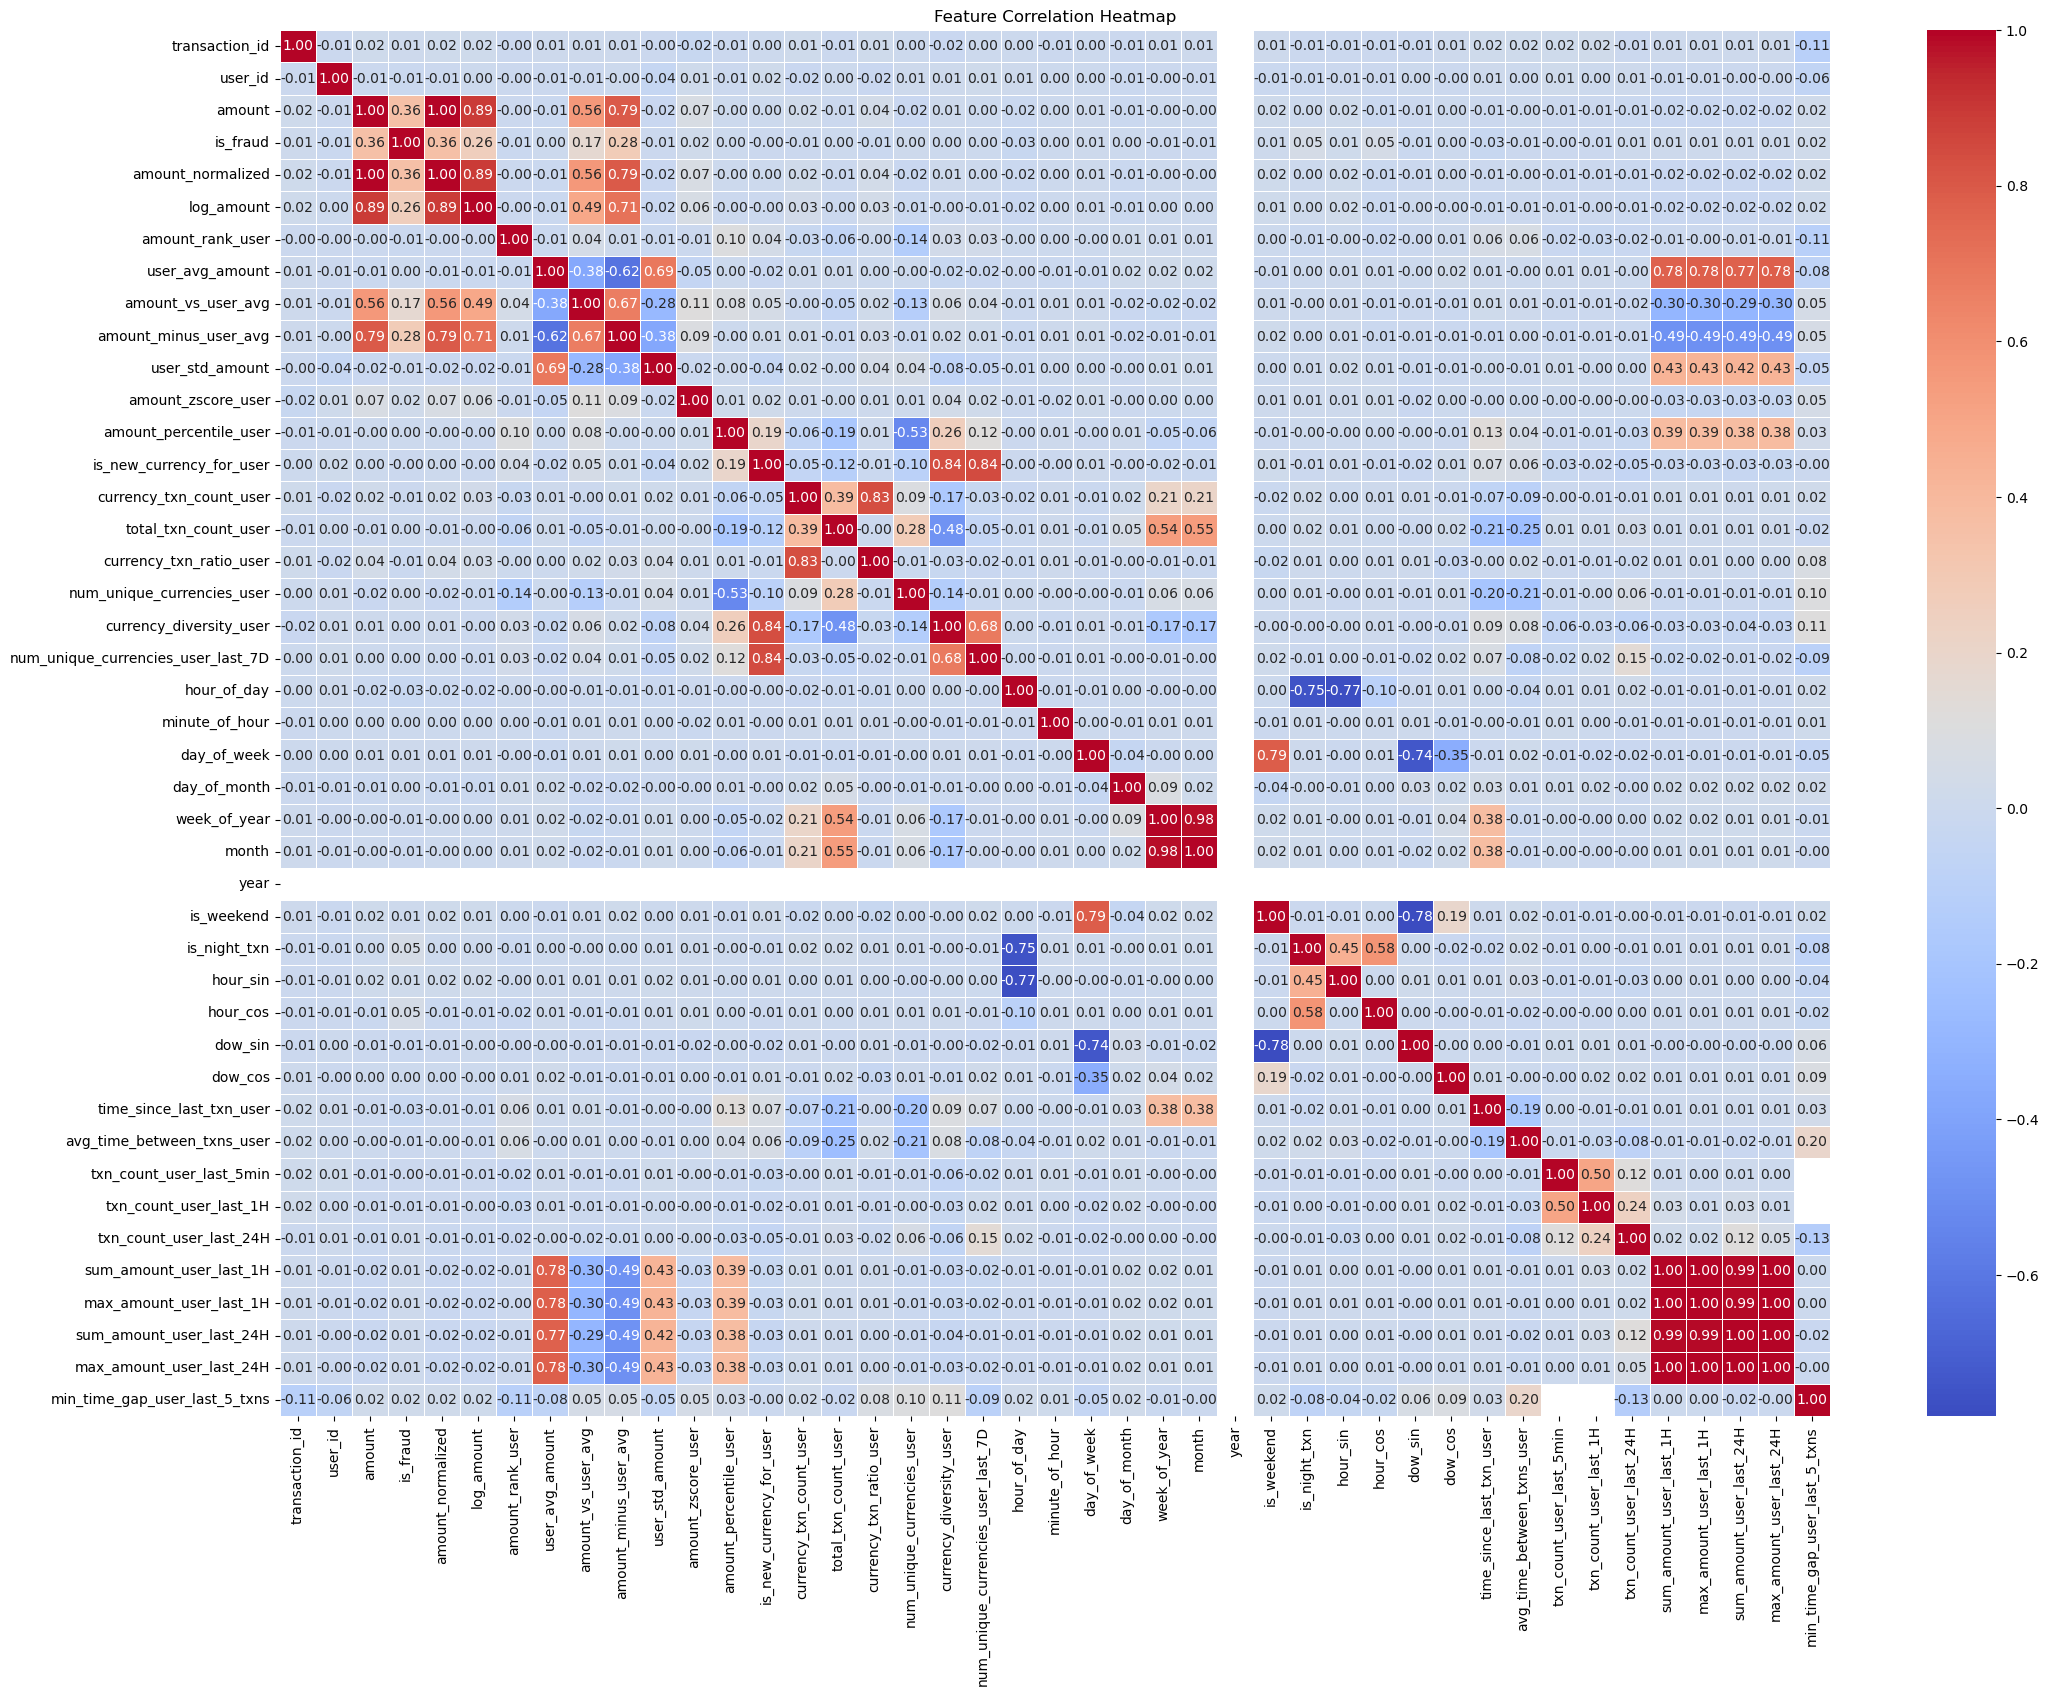

In [20]:
# 1. Compute the correlation matrix
# 'numeric_only=True' ensures you don't hit errors with string columns
corr = preprocessed_df.corr(numeric_only=True)

# 2. Set up the matplotlib figure
plt.figure(figsize=(25, 18))

# 3. Draw the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.show()

## There seems to be a positive correlation between fraud commited and amount features. This proves fraud is commited on larger amounts. 

In [21]:
def remove_highly_correlated(df, threshold=0.9):
    corr_matrix = df.corr(numeric_only=True).abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    df_dropped = df.drop(columns=to_drop)
    
    print(f"Dropped {len(to_drop)} columns: {to_drop}")
    return df_dropped
preprocessed_df_new = remove_highly_correlated(preprocessed_df, threshold=0.85)

Dropped 6 columns: ['amount_normalized', 'log_amount', 'month', 'max_amount_user_last_1H', 'sum_amount_user_last_24H', 'max_amount_user_last_24H']


In [22]:
len(preprocessed_df_new.columns)

37

In [23]:
transaction_ids = preprocessed_df_new['transaction_id']
is_fraud = preprocessed_df_new['is_fraud']
preprocessed_df_new = preprocessed_df_new.drop(['transaction_id', 'is_fraud'], axis=1)

In [24]:
preprocessed_df_new = preprocessed_df_new.fillna(preprocessed_df_new.mean())

In [25]:
X = preprocessed_df_new
y = is_fraud
train_x, test_x, train_y, test_y = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(7500, 35)
(7500,)
(2500, 35)
(2500,)


In [26]:
ss = StandardScaler()
train_x = ss.fit_transform(train_x)
test_x = ss.transform(test_x)

In [27]:
train_x

array([[-1.58598645,  2.36062438, -2.39747732, ..., -0.07948921,
        -0.8656404 , -0.0035079 ],
       [-1.03598646,  1.64085615, -1.76811562, ..., -0.07948921,
        -0.74820022, -0.0035079 ],
       [ 0.07704669, -0.022379  ,  0.74933119, ..., -0.07948921,
         0.98602674, -0.0035079 ],
       ...,
       [-0.1723214 , -0.33197926,  0.74933119, ..., -0.07948921,
        -0.71045737, -0.0035079 ],
       [-1.57208439, -0.51844855, -2.08279647, ..., -0.07948921,
        -1.02876075, -0.0035079 ],
       [ 0.69047479, -0.86624521,  0.74933119, ..., -0.07948921,
        -0.14431472, -0.0035079 ]], shape=(7500, 35))

In [28]:
lr = LogisticRegression()
lr.fit(train_x, train_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
pred_lr = lr.predict(test_x)

In [30]:
cm = confusion_matrix(test_y, pred_lr, labels=[0, 1])
cm

array([[2332,    7],
       [ 140,   21]])

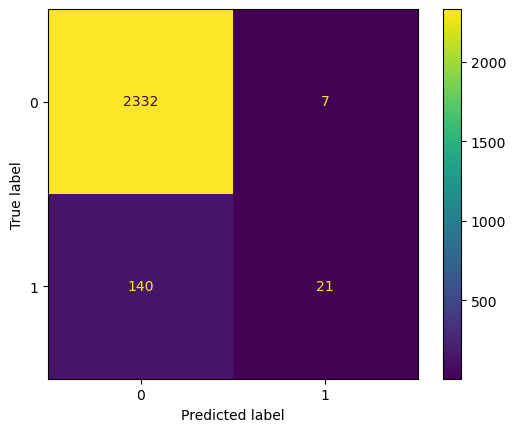

In [31]:
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot()
plt.show()

In [32]:
f1_score(test_y, pred_lr)

0.2222222222222222

In [33]:
accuracy_score(test_y, pred_lr)

0.9412

==================================================

In [34]:
rfc = RandomForestClassifier()
rfc.fit(train_x, train_y)
pred_rfc = rfc.predict(test_x)

In [35]:
cm = confusion_matrix(test_y, pred_rfc, labels=[0, 1])
cm

array([[2328,   11],
       [ 141,   20]])

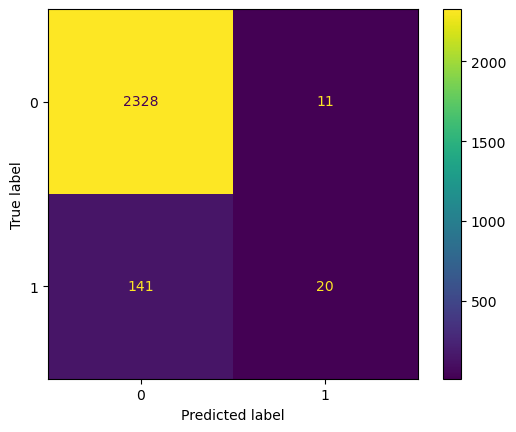

In [36]:
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot()
plt.show()

In [37]:
f1_score(test_y, pred_rfc)

0.20833333333333334

In [38]:
accuracy_score(test_y, pred_rfc)

0.9392

===================================================================

In [39]:
xgb = XGBClassifier()
xgb.fit(train_x, train_y)
pred_xgb = xgb.predict(test_x)

In [40]:
cm = confusion_matrix(test_y, pred_xgb, labels=[0, 1])
cm

array([[2319,   20],
       [ 140,   21]])

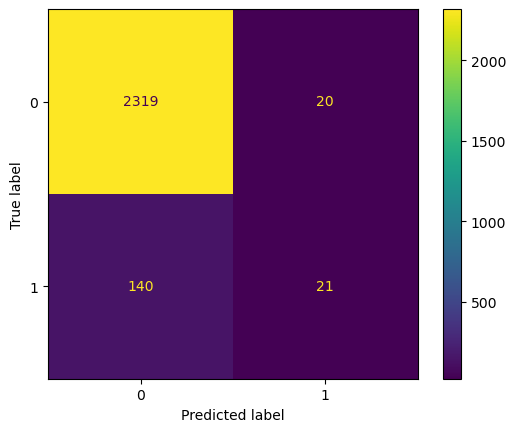

In [41]:
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot()
plt.show()

In [42]:
f1_score(test_y, pred_xgb)

0.2079207920792079

In [43]:
accuracy_score(test_y, pred_xgb)

0.936